# Smart Agriculture Monitoring System

## FLM Projekt

Name: Nicole Storf

Klasse: 4AAME

Datum: 01.06. 2026

# Phase 1 – Projektplanung

## Projektname
Smart Agriculture Monitoring System

## Zielsetzung
Überwachung eines Gewächshauses mit Sensordaten und Analyse der Messwerte.

## Stakeholder
- Landwirt
- Betriebsleitung
- IT-Administrator

## Funktionale Anforderungen
- Sensordaten speichern
- Statistiken berechnen
- Warnungen anzeigen
- API bereitstellen

## Nichtfunktionale Anforderungen
- Benutzerfreundlich
- Erweiterbar
- Sicher

## Risiken
- Datenverlust
- Fehlende Authentifizierung
- Zeitmangel

## Deliverables
- CSV-Datei
- API-Konzept
- Analyse
- Flutter-App
- Dokumentation

# Phase 2 – Datengenerierung

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
np.random.seed(42)

n = 120

start_time = datetime.now() - timedelta(hours=n)

timestamps = [
    start_time + timedelta(hours=i)
    for i in range(n)
]

In [3]:
data = pd.DataFrame({
    "timestamp": timestamps,
    "soil_moisture_percent": np.random.normal(45, 8, n).clip(20, 80),
    "soil_temperature_c": np.random.normal(21, 2, n).clip(15, 30),
    "air_temperature_c": np.random.normal(24, 3, n).clip(16, 35),
    "air_humidity_percent": np.random.normal(60, 10, n).clip(30, 90),
    "ph_value": np.random.normal(6.5, 0.25, n).clip(5.6, 7.4)
})

In [4]:
data["irrigation_active"] = data["soil_moisture_percent"] < 38

def get_status(row):
    if row["ph_value"] < 5.8 or row["ph_value"] > 7.2:
        return "Critical"
    elif row["soil_moisture_percent"] < 35 or row["air_temperature_c"] > 30:
        return "Warning"
    else:
        return "OK"

data["system_status"] = data.apply(get_status, axis=1)

data.head()

,timestamp,soil_moisture_percent,soil_temperature_c,air_temperature_c,air_humidity_percent,ph_value,irrigation_active,system_status
0,2026-05-27 12:17:10.574207,48.973713,22.582064,21.622438,65.193465,6.468021,False,OK
1,2026-05-27 13:17:10.574207,43.893886,19.181225,23.655791,75.327389,6.261115,False,OK
2,2026-05-27 14:17:10.574207,50.181508,23.805589,25.514962,58.912399,6.098388,False,OK
3,2026-05-27 15:17:10.574207,57.184239,18.196298,26.597266,64.017117,6.550866,False,OK
4,2026-05-27 16:17:10.574207,43.126773,22.173714,20.399111,66.901440,6.310912,False,OK


In [5]:
data.to_csv("smart_agriculture_sensor_data.csv", index=False)

print("CSV-Datei erfolgreich erstellt.")

CSV-Datei erfolgreich erstellt.


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   timestamp              120 non-null    datetime64[us]
 1   soil_moisture_percent  120 non-null    float64       
 2   soil_temperature_c     120 non-null    float64       
 3   air_temperature_c      120 non-null    float64       
 4   air_humidity_percent   120 non-null    float64       
 5   ph_value               120 non-null    float64       
 6   irrigation_active      120 non-null    bool          
 7   system_status          120 non-null    str           
dtypes: bool(1), datetime64[us](1), float64(5), str(1)
memory usage: 6.8 KB


# Phase 4 – Datenanalyse

In [7]:
LSL = 5.8
TARGET = 6.5
USL = 7.2

ph = data["ph_value"]

mean = ph.mean()
median = ph.median()
variance = ph.var()
std_dev = ph.std()

cp = (USL - LSL) / (6 * std_dev)

cpk = min(
    (USL - mean) / (3 * std_dev),
    (mean - LSL) / (3 * std_dev)
)

print(f"Mittelwert: {mean:.3f}")
print(f"Median: {median:.3f}")
print(f"Varianz: {variance:.3f}")
print(f"Standardabweichung: {std_dev:.3f}")
print(f"Cp: {cp:.3f}")
print(f"Cpk: {cpk:.3f}")

Mittelwert: 6.466
Median: 6.457
Varianz: 0.055
Standardabweichung: 0.234
Cp: 0.997
Cpk: 0.949


## Interpretation der Ergebnisse

Der durchschnittliche pH-Wert beträgt 6,466 und liegt damit nahe am Zielwert von 6,5. Der Median liegt ebenfalls nahe am Mittelwert, was auf eine gleichmäßige Verteilung der Daten hindeutet.

Die Standardabweichung von 0,234 zeigt eine moderate Streuung der Messwerte.

Der Prozessfähigkeitsindex Cp beträgt 0,997. Ein Cp-Wert von mindestens 1,33 wäre für einen stabilen Prozess wünschenswert. Daher besteht Verbesserungspotenzial.

Der Cpk-Wert von 0,949 zeigt, dass der Prozess nicht vollständig innerhalb der gewünschten Spezifikationsgrenzen arbeitet. Eine Optimierung der pH-Regelung wäre sinnvoll.

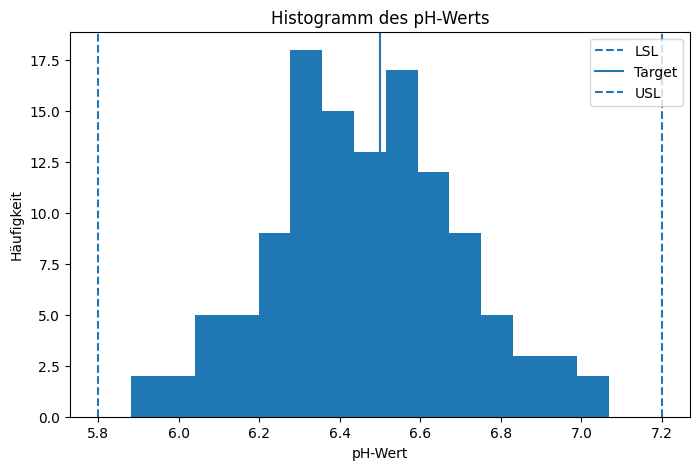

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(ph, bins=15)

plt.axvline(LSL, linestyle="--", label="LSL")
plt.axvline(TARGET, linestyle="-", label="Target")
plt.axvline(USL, linestyle="--", label="USL")

plt.title("Histogramm des pH-Werts")
plt.xlabel("pH-Wert")
plt.ylabel("Häufigkeit")
plt.legend()

plt.show()

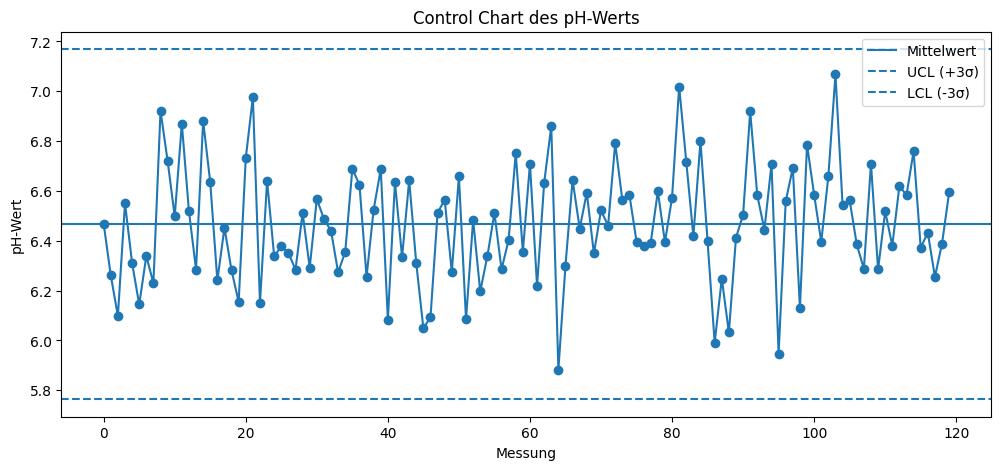

In [9]:
mean = ph.mean()
std = ph.std()

UCL = mean + 3 * std
LCL = mean - 3 * std

plt.figure(figsize=(12,5))

plt.plot(ph.values, marker="o")

plt.axhline(mean, linestyle="-", label="Mittelwert")
plt.axhline(UCL, linestyle="--", label="UCL (+3σ)")
plt.axhline(LCL, linestyle="--", label="LCL (-3σ)")

plt.title("Control Chart des pH-Werts")
plt.xlabel("Messung")
plt.ylabel("pH-Wert")
plt.legend()

plt.show()

# Phase 3 – REST API Konzept

## API-Endpunkte

### GET /sensors

Beschreibung:
Liefert die aktuellen Sensordaten des Gewächshauses.

Beispielantwort:

{
  "soil_moisture_percent": 45.2,
  "soil_temperature_c": 21.4,
  "air_temperature_c": 24.1,
  "air_humidity_percent": 62.3,
  "ph_value": 6.5
}

---

### GET /statistics

Beschreibung:
Liefert statistische Kennzahlen zum pH-Wert.

Beispielantwort:

{
  "mean": 6.466,
  "median": 6.457,
  "std_dev": 0.234,
  "cp": 0.997,
  "cpk": 0.949
}

---

### GET /alerts

Beschreibung:
Liefert aktuelle Warnungen und kritische Zustände.

Beispielantwort:

{
  "alerts": [
    "Bodenfeuchtigkeit zu niedrig",
    "pH-Wert außerhalb der Spezifikation"
  ]
}

---

### POST /login

Beschreibung:
Authentifiziert einen Benutzer.

Request:

{
  "username": "admin",
  "password": "******"
}

Response:

{
  "token": "abc123xyz"
}

---

### GET /health

Beschreibung:
Überprüft den Systemzustand.

Response:

{
  "status": "OK"
}

## Systemarchitektur

Sensoren
↓
CSV-Datenspeicherung
↓
Python Datenanalyse
↓
REST API (FastAPI)
↓
Flutter Desktop Dashboard
↓
Benutzer

# Phase 5 – Cybersecurity Review

| Risiko | Wahrscheinlichkeit | Auswirkung | Risikostufe | Maßnahme |
|----------|------------------|-------------|-------------|-----------|
| Keine Authentifizierung | Hoch | Hoch | Kritisch | Login-System einführen |
| Hardcodierte Passwörter | Mittel | Hoch | Hoch | Passwörter verschlüsseln |
| Keine Eingabevalidierung | Hoch | Mittel | Hoch | Eingaben prüfen |
| Keine Rate Limits | Mittel | Mittel | Mittel | API-Anfragen begrenzen |
| Fehlende Autorisierung | Hoch | Hoch | Kritisch | Rollen und Rechte definieren |

## Zusammenfassung

Die größten Risiken bestehen in fehlender Authentifizierung und Autorisierung. Diese könnten zu unbefugtem Zugriff auf Sensordaten führen. Durch Login-Mechanismen, Rollenverwaltung und sichere Passwortspeicherung kann das Risiko deutlich reduziert werden.

# Phase 6 – Flutter Windows Desktop App

## Geplante Screens

### Dashboard

Anzeigen:
- Bodenfeuchtigkeit
- Bodentemperatur
- Lufttemperatur
- Luftfeuchtigkeit
- pH-Wert
- Systemstatus

### Analyse

Anzeigen:
- Mittelwert
- Median
- Standardabweichung
- Cp
- Cpk
- Histogramm

### Security & Alerts

Anzeigen:
- Aktuelle Warnungen
- Cybersecurity-Risiken
- Systemmeldungen

### Projektinfo

Anzeigen:
- Projektbeschreibung
- Systemarchitektur
- Entwicklerinformationen


## Beispielhafte Benutzeroberfläche

Das Dashboard zeigt die aktuellen Sensordaten in Kartenform an. Kritische Werte werden hervorgehoben. Zusätzlich werden statistische Kennzahlen sowie Warnmeldungen übersichtlich dargestellt.

Der Benutzer kann zwischen Dashboard, Analyse, Security und Projektinformationen wechseln.

# Phase 7 – Dokumentation

## Projektziel

Entwicklung eines Smart-Agriculture-Systems zur Überwachung eines Gewächshauses.

## Datenmodell

Die Sensordaten werden in einer CSV-Datei gespeichert.

Attribute:
- timestamp
- soil_moisture_percent
- soil_temperature_c
- air_temperature_c
- air_humidity_percent
- ph_value
- irrigation_active
- system_status

## API-Design

Die Daten werden über REST-Endpunkte bereitgestellt:
- /sensors
- /statistics
- /alerts
- /login
- /health

## Datenanalyse

Der pH-Wert wurde statistisch ausgewertet. Zusätzlich wurden Histogramm und Regelkarte erstellt.

## Cybersecurity

Es wurden Sicherheitsrisiken identifiziert und Gegenmaßnahmen vorgeschlagen.

## Flutter-App

Für die Visualisierung der Daten wurde ein Dashboard-Konzept erstellt.

## Lessons Learned

- Datenanalyse mit Python
- Erstellung von REST-APIs
- Grundlagen der Cybersecurity
- Planung einer Flutter-Anwendung